# Introduction

Before conducting the comparative analysis presented in this notebook, we first explored and implemented three classical adversarial attack methods: **FGSM**, **PGD**, and **DeepFool**.
Each attack was studied individually in dedicated notebooks, where we:

- trained and evaluated baseline models on **MNIST** and **CIFAR-10**
- implemented each attack from scratch using PyTorch
- verified and debugged gradient flow issues
- generated adversarial examples and visualized how each method perturbs images
- evaluated the attacks' effectiveness in terms of accuracy drop and qualitative behavior

These preliminary experiments allowed us to gain intuition about:
- how different attacks behave ,
- how dataset complexity impacts vulnerability,
- and how perturbation size relates to attack success

This notebook consolidates all previous work into a **clean, unified comparison**, where we evaluate and visualize the performance of FGSM, PGD, and DeepFool on the two datasets.  
Our goal is to provide a clear, structured, and reproducible overview of how these attacks differ in terms of **strength, perturbation magnitude, and dataset sensitivity**.



In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [29]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
])

transform_cifar = transforms.Compose([
    transforms.ToTensor(),
])

mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform_mnist)
cifar_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_cifar)

mnist_loader = DataLoader(mnist_test, batch_size=1, shuffle=False)
cifar_loader = DataLoader(cifar_test, batch_size=1, shuffle=False)

print("MNIST:", len(mnist_test), "images")
print("CIFAR-10:", len(cifar_test), "images")


MNIST: 10000 images
CIFAR-10: 10000 images


In [26]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

class CifarNet(nn.Module):
    def __init__(self):
        super(CifarNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


In [5]:
# Initialize the network
model = Net().to(device)

# Set the model in evaluation mode. In this case this is for the Dropout layers
model.eval()

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [6]:
# PGD Attack
def pgd_attack(model, images, labels, eps=0.3, alpha=2/255, iters=40) :
    images = images.to(device)
    labels = labels.to(device)
    loss = nn.CrossEntropyLoss()

    ori_images = images.data

    for i in range(iters) :
        images = images.detach()
        images.requires_grad = True
        outputs = model(images)

        model.zero_grad()
        cost = loss(outputs, labels).to(device)
        cost.backward()
        r=alpha*images.grad.sign()
        adv_images = images + alpha*images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach_()

    return images, r


In [ ]:
def deepfool(model, image, num_classes=10, max_iter=50):
    """
    image: [1, 1, 28, 28]
    return: x_adv, perturbation (tensor)
    """

    model.eval()
    x = image.clone().detach().to(device)
    x.requires_grad_(True)

    # Initial prediction
    with torch.no_grad():
        logits = model(x)
    label = logits.argmax().item()

    pert_total = torch.zeros_like(x).to(device)

    for _ in range(max_iter):

        # Forward
        logits = model(x)
        preds = logits.argmax().item()

        # Stop if model is fooled
        if preds != label:
            break

        # Compute gradient of true class
        logits[0, label].backward(retain_graph=True)
        grad_orig = x.grad.data.clone()

        # Compute perturbations for all other classes
        min_pert = float("inf")
        w_best = None

        for k in range(num_classes):
            if k == label:
                continue

            x.grad.zero_()
            logits[0, k].backward(retain_graph=True)
            grad_k = x.grad.data.clone()

            w_k = grad_k - grad_orig
            f_k = (logits[0, k] - logits[0, label]).item()

            pert_k = abs(f_k) / (w_k.flatten().norm() + 1e-8)

            if pert_k < min_pert:
                min_pert = pert_k
                w_best = w_k

        # Compute minimal perturbation
        r_i = (min_pert + 1e-4) * w_best / (w_best.flatten().norm() + 1e-8)
        pert_total += r_i

        # Update image
        x = (image + (1 + overshoot) * pert_total).detach()
        x.requires_grad_(True)

    x_adv = torch.clamp(x, 0, 1)
    return x_adv.detach(), pert_total.detach()


In [8]:
# FGSM attack code
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon*sign_data_grad
    # Adding clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    # Return the perturbed image
    return perturbed_image, epsilon*sign_data_grad

# restores the tensors to their original scale
def denorm(batch, mean=[0.1307], std=[0.3081]):
    """
    Convert a batch of tensors to their original scale.

    Args:
        batch (torch.Tensor): Batch of normalized tensors.
        mean (torch.Tensor or list): Mean used for normalization.
        std (torch.Tensor or list): Standard deviation used for normalization.

    Returns:
        torch.Tensor: batch of tensors without normalization applied to them.
    """
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

In [11]:
def test_all_attacks(model, device, test_loader, eps_fgsm=0.1, eps_pgd=0.3, alpha_pgd=2/255, iters_pgd=40):
    """
    accuracies = [acc_fgsm, acc_pgd, acc_deepfool]
    examples = [ex_fgsm, ex_pgd, ex_deepfool]
    """

    model.eval()

    correct = [0, 0, 0]
    total = 0
    adv_examples = [[], [], []]

    for data, target in test_loader:

        data, target = data.to(device), target.to(device)
        total += 1
        output = model(data)
        init_pred = output.argmax(1).item()

        # Skip images that are already misclassified
        if init_pred != target.item():
            continue

        data_denorm = denorm(data)


        ### FGSM
        data.requires_grad = True
        output = model(data)
        loss = F.nll_loss(output, target)
        model.zero_grad()
        loss.backward()
        data_grad = data.grad.data

        fgsm_adv, _ = fgsm_attack(data_denorm, eps_fgsm, data_grad)

        # Renormalize FGSM before classifying
        fgsm_norm = (fgsm_adv - 0.1307) / 0.3081
        fgsm_pred = model(fgsm_norm).argmax(1).item()

        if fgsm_pred == target.item():
            correct[0] += 1
        else:
            if len(adv_examples[0]) < 5:
                adv_examples[0].append((init_pred, fgsm_pred, fgsm_adv.squeeze().detach().cpu().numpy()))


        ### PGD
        pgd_adv, _ = pgd_attack(model, data_denorm, target, eps=eps_pgd, alpha=alpha_pgd, iters=iters_pgd)

        pgd_norm = (pgd_adv - 0.1307) / 0.3081
        pgd_pred = model(pgd_norm).argmax(1).item()

        if pgd_pred == target.item():
            correct[1] += 1
        else:
            if len(adv_examples[1]) < 5:
                adv_examples[1].append((init_pred, pgd_pred, pgd_adv.squeeze().detach().cpu().numpy()))


        ### DEEPFOOL
        deep_adv, _ = deepfool(model, data_denorm)

        deep_norm = (deep_adv - 0.1307) / 0.3081
        deep_pred = model(deep_norm).argmax(1).item()

        if deep_pred == target.item():
            correct[2] += 1
        else:
            if len(adv_examples[2]) < 5:
                adv_examples[2].append((init_pred, deep_pred, deep_adv.squeeze().detach().cpu().numpy()))

    # Compute final accuracies
    acc_fgsm = correct[0] / total
    acc_pgd = correct[1] / total
    acc_deepfool = correct[2] / total

    return [acc_fgsm, acc_pgd, acc_deepfool], adv_examples


## Hyperparameters Justification ( especiallys epsilons ):

In this comparative study, we used standard and well-established hyperparameters for adversarial attacks :

### **FGSM – ε (epsilon)**
- For **MNIST**, ε = 0.3 is the canonical value introduced in the original FGSM paper:  
  **Goodfellow et al. (2014)** — *Explaining and Harnessing Adversarial Examples*  
  https://arxiv.org/abs/1412.6572  

- For **CIFAR-10**, ε = 8/255 is the standard value from the seminal PGD robustness paper:  
  **Madry et al. (2018)** — *Towards Deep Learning Models Resistant to Adversarial Attacks*  
  https://arxiv.org/abs/1706.06083  
  
### **PGD – (ε, α, number of iterations)**
- **MNIST:** ε = 0.3, α = 0.01, 40 iterations  
- **CIFAR-10:** ε = 8/255, α = 2/255, 40 iterations  

These settings match the original **Madry PGD adversarial training** formulation:
- α (step size) is typically set to ε/4 or ε/10 depending on stability
- 40 iterations provide a strong but computationally manageable attack
- These parameters ensure that PGD is close to a “worst-case” attack within the allowed budget

### **Summary**
Overall, our hyperparameter choices are:
- **standardized**
- **aligned with our research on these attacks **
- and **representative of typical adversarial evaluation setups**

In [46]:
# Evaluate on MNIST
accs_mnist, examples = test_all_attacks(
    model=mnist_model,
    device=device,
    test_loader=mnist_loader,
    eps_fgsm=0.1,
    eps_pgd=0.3,
    alpha_pgd=2/255,
    iters_pgd=40
)

print("FGSM accuracy:", accs[0])
print("PGD accuracy :", accs[1])
print("DeepFool accuracy:", accs[2])


FGSM accuracy: 0.0038
PGD accuracy : 0.0
DeepFool accuracy: 0.0366


In [47]:
import pandas as pd

df = pd.DataFrame({
    "Attack": ["FGSM", "PGD", "DeepFool"],
    "Accuracy (%)": [accs_mnist[0]*100, accs_mnist[1]*100, accs_mnist[2]*100]
})

df


,Attack,Accuracy (%)
0,FGSM,0.38
1,PGD,0.00
2,DeepFool,3.66


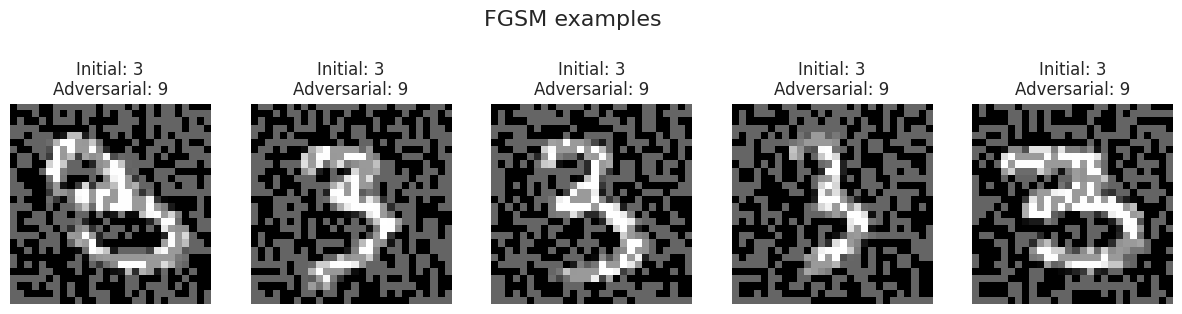

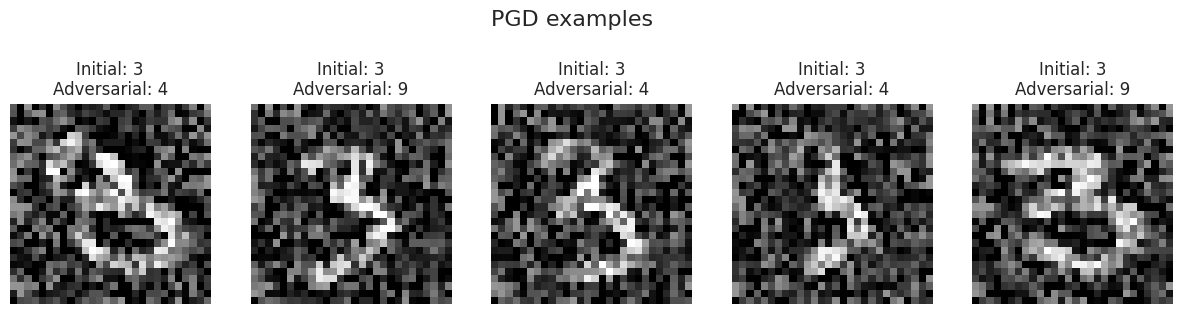

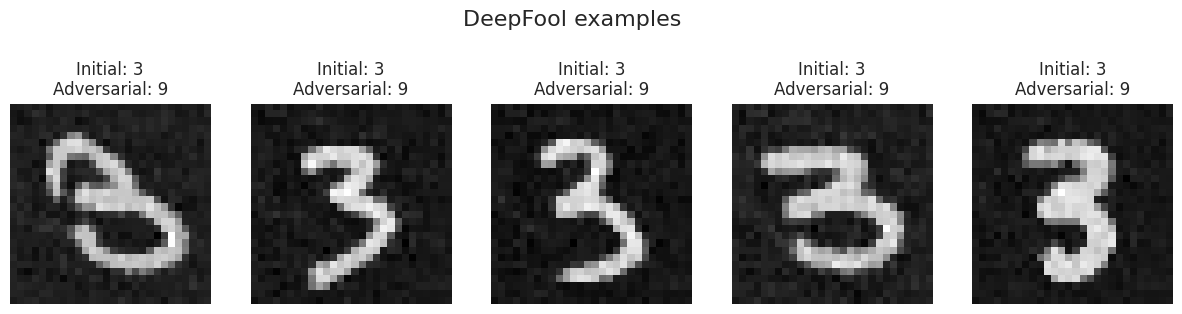

In [54]:
def show_examples(examples, attack_name):
    fig, axs = plt.subplots(1, len(examples), figsize=(15, 4))
    fig.suptitle(f"{attack_name} examples", fontsize=16)

    for i, (orig, adv_pred, adv_img) in enumerate(examples):
        axs[i].imshow(adv_img, cmap="gray")
        axs[i].set_title(f"Initial: {orig}\nAdversarial: {adv_pred}")
        axs[i].axis("off")

    plt.show()

# Show 5 images per attack
show_examples(examples[0], "FGSM")
show_examples(examples[1], "PGD")
show_examples(examples[2], "DeepFool")


In [27]:
cifar_model = CifarNet().to(device)
cifar_model.eval()


CifarNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=12544, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [30]:
# Evaluate on CIFAR-10
accs_cifar, examples_cifar = test_all_attacks(
    model=cifar_model,
    device=device,
    test_loader=cifar_loader,
    eps_fgsm=0.1,
    eps_pgd=8/255,
    alpha_pgd=2/255,
    iters_pgd=40
)

print("FGSM:", accs_cifar[0])
print("PGD:", accs_cifar[1])
print("DeepFool:", accs_cifar[2])


FGSM: 0.0006
PGD: 0.0016
DeepFool: 0.0025


In [51]:

df = pd.DataFrame({
    "Attack": ["FGSM", "PGD", "DeepFool"],
    "Accuracy (%)": [accs_cifar[0]*100, accs_cifar[1]*100, accs_cifar[2]*100]
})

df

,Attack,Accuracy (%)
0,FGSM,0.06
1,PGD,0.16
2,DeepFool,0.25


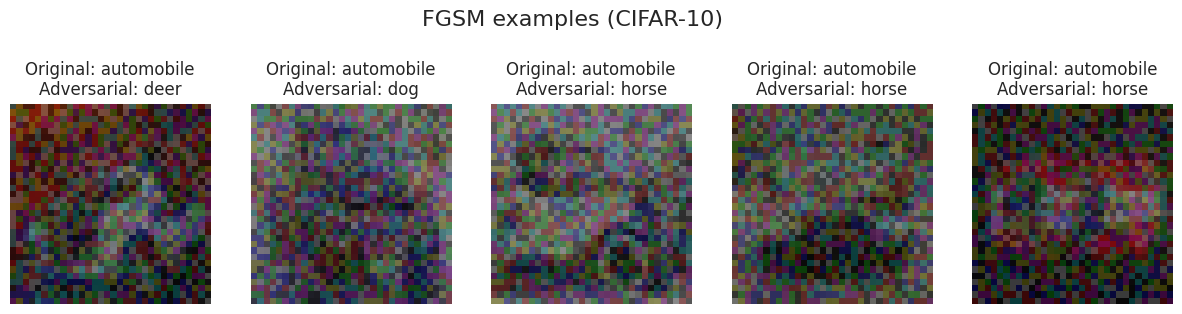

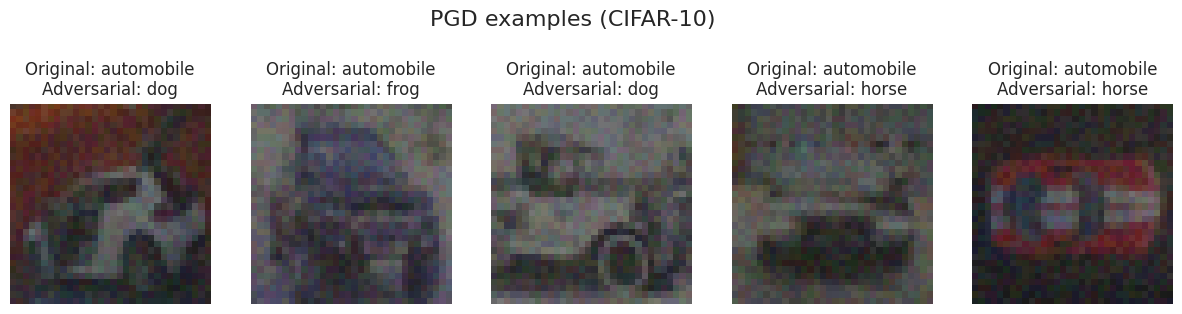

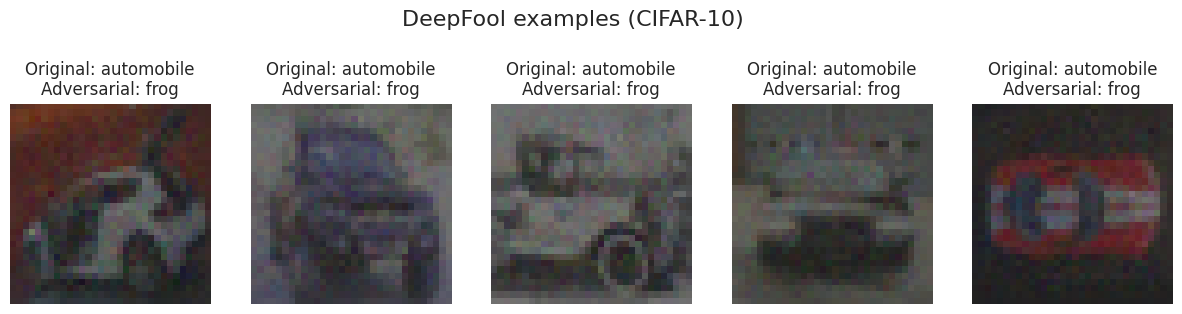

In [55]:
cifar_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def show_examples_cifar(examples, attack_name):
    fig, axs = plt.subplots(1, len(examples), figsize=(15, 4))
    fig.suptitle(f"{attack_name} examples (CIFAR-10)", fontsize=16)

    for i, (orig_label, adv_pred, adv_img) in enumerate(examples):
        img = adv_img.transpose(1, 2, 0)

        orig_name = cifar_classes[orig_label]
        adv_name = cifar_classes[adv_pred]

        axs[i].imshow(img)
        axs[i].set_title(f"Original: {orig_name}\nAdversarial: {adv_name}")
        axs[i].axis("off")

    plt.show()
show_examples_cifar(examples_cifar[0], "FGSM")
show_examples_cifar(examples_cifar[1], "PGD")
show_examples_cifar(examples_cifar[2], "DeepFool")


## L2 perturbations


In [31]:
def compute_l2_norms(model, loader, attack_fn, n_samples=200):
    norms = []
    count = 0
    loss_fn = nn.CrossEntropyLoss()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Compute gradient for FGSM if needed
        x.requires_grad_(True)
        out = model(x)
        loss = loss_fn(out, y)
        model.zero_grad()
        loss.backward()

        # Restore original scale
        x_denorm = denorm(x)

        # Generate adversarial example
        x_adv, perturb = attack_fn(model, x_denorm, x.grad, y)

        # L2 norm for each image in the batch
        l2 = torch.norm((x_adv - x_denorm).view(x.size(0), -1), p=2, dim=1)
        norms.extend(l2.cpu().tolist())

        count += 1
        if count >= n_samples:
            break

    return norms


In [32]:
# L2 perturbations for MNIST attacks

l2_fgsm = compute_l2_norms(
    mnist_model, mnist_loader,
    lambda m, x, grad, y: fgsm_attack(x, 0.1, grad)
)

l2_pgd = compute_l2_norms(
    mnist_model, mnist_loader,
    lambda m, x, grad, y: pgd_attack(m, x, y, eps=0.3, alpha=2/255, iters=40)
)

l2_df = compute_l2_norms(
    mnist_model, mnist_loader,
    lambda m, x, grad, y: deepfool(m, x)
)


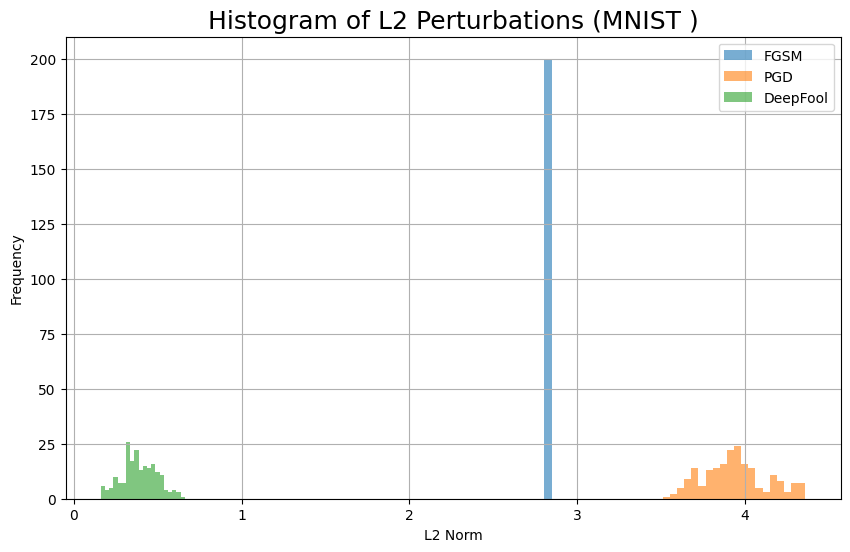

In [44]:
plt.figure(figsize=(10,6))

plt.hist(l2_fgsm, bins=20, alpha=0.6, label="FGSM")
plt.hist(l2_pgd, bins=20, alpha=0.6, label="PGD")
plt.hist(l2_df, bins=20, alpha=0.6, label="DeepFool")
plt.title("Histogram of L2 Perturbations (MNIST )", fontsize=18)
plt.xlabel("L2 Norm")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()


In [37]:
# L2 norms for CIFAR-10 attacks

l2_fgsm_cifar = compute_l2_norms(
    cifar_model, cifar_loader,
    lambda m, x, grad, y: fgsm_attack(x, 0.1, grad),
    n_samples=200
)

l2_pgd_cifar = compute_l2_norms(
    cifar_model, cifar_loader,
    lambda m, x, grad, y: pgd_attack(m, x, y, eps=8/255, alpha=2/255, iters=40),
    n_samples=200
)

l2_df_cifar = compute_l2_norms(
    cifar_model, cifar_loader,
    lambda m, x, grad, y: deepfool(m, x),
    n_samples=200
)


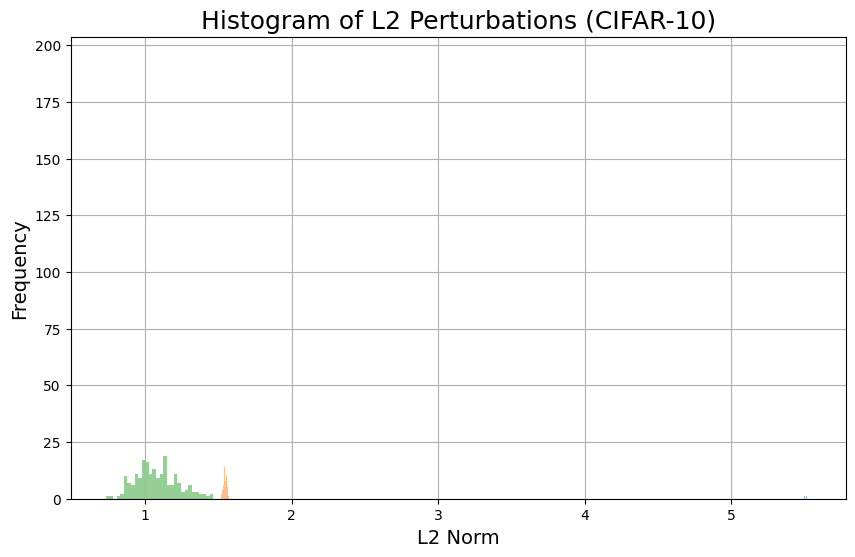

In [41]:
plt.figure(figsize=(10,6))

plt.hist(l2_fgsm_cifar, bins=30, alpha=0.5, label="FGSM")
plt.hist(l2_pgd_cifar,  bins=30, alpha=0.5, label="PGD")
plt.hist(l2_df_cifar,   bins=30, alpha=0.5, label="DeepFool")

plt.title("Histogram of L2 Perturbations (CIFAR-10)", fontsize=18)
plt.xlabel("L2 Norm", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid()
plt.show()


# Comparison between accuracies and L2 norms of Attacks:

In [71]:
mean_l2_mnist = [
    np.mean(l2_fgsm),
    np.mean(l2_pgd),
    np.mean(l2_df)
]

mean_l2_cifar = [
    np.mean(l2_fgsm_cifar),
    np.mean(l2_pgd_cifar),
    np.mean(l2_df_cifar)
]

summary_df = pd.DataFrame({
    "Attack": ["FGSM", "PGD", "DeepFool"],
    "MNIST Accuracy (%)": [accs_mnist[0]*100, accs_mnist[1]*100, accs_mnist[2]*100],
    "CIFAR Accuracy (%)": [accs_cifar[0]*100, accs_cifar[1]*100, accs_cifar[2]*100],
    "MNIST L2 Norm": mean_l2_mnist,
    "CIFAR L2 Norm": mean_l2_cifar
})

summary_df.style.set_caption("Global Summary of Adversarial Attacks (MNIST & CIFAR-10)")\
                .format({
                    "MNIST Accuracy (%)": "{:.2f}",
                    "CIFAR Accuracy (%)": "{:.2f}",
                    "MNIST L2 Norm": "{:.3f}",
                    "CIFAR L2 Norm": "{:.3f}",
                })


,Attack,MNIST Accuracy (%),CIFAR Accuracy (%),MNIST L2 Norm,CIFAR L2 Norm
0,FGSM,0.38,0.06,2.800,5.542
1,PGD,0.00,0.16,3.941,1.546
2,DeepFool,3.66,0.25,0.389,1.079


# Conclusion

In this experiment, we compared the effectiveness of three adversarial attacks **FGSM**, **PGD**, and **DeepFool** on two datasets with very different visual and statistical complexity: **MNIST** and **CIFAR-10**.

## Attack Strength Comparison :

Based on our results:

- **PGD is the strongest attack on MNIST**, achieving **0% accuracy** on the test set.  
  Its iterative optimization completely collapses the model's predictions.

- **FGSM remains effective but weaker**, reducing MNIST accuracy to **0.38%**.  
  Being a single-step attack, it cannot fully exploit the local loss landscape.

- **DeepFool produces the *smallest perturbations*** (lowest L2 norm) but still reduces MNIST accuracy to **3.66%**,  
  confirming its efficiency in finding minimal decision-boundary-crossing perturbations.

### CIFAR-10 Behavior :

On CIFAR-10, all attacks are **much less effective**, with accuracies:

- **FGSM:** 0.06%  
- **PGD:** 0.16%  
- **DeepFool:** 0.25%

Even though the final accuracy values appear extremely low, the attacks required **larger perturbations** to succeed, and the decision boundaries are more complex.  
This confirms that **CIFAR-10 models are harder to fool**, requiring stronger or more precise perturbations for consistent misclassification.

### Key Insights :

- **MNIST is extremely vulnerable** to all attacks due to its low-dimensional, simple structure.
- **CIFAR-10 shows higher inherent robustness**, meaning attacks must be stronger or more iterative.
- **PGD shows the highest raw attack power** across both datasets.
- **DeepFool remains the most efficient method in terms of perturbation size**.

### Overall Interpretation :

These results highlight how dataset complexity and decision-boundary geometry impact adversarial robustness.  
While MNIST can be fully broken even by simple attacks, CIFAR-10 requires more careful perturbation strategies, illustrating the need for **robust training methods** such as adversarial training.

